# End-to-end dapper tutorial

This notebook walks through a **minimal** end-to-end dapper workflow for three 0.5° × 0.5° grid cells. It highlights the core functionality of `dapper` but does not get into details. Other notebooks do deeper dives into elements of `dapper` functionality.

`dapper` supports two run modes:

- **`mode="sites"`**: *one set of ELM files per geometry* (per grid cell in our case here, or `gid` in `dapper` terminology).
- **`mode="cellset"`**: *one set of ELM files total* containing multiple grid cells.

This notebook uses `mode="sites"`, but the workflow remains the same if you want to use `mode="cellset"`. 

Important: **“sites” does _not_ mean at-a-point.** Your *input geometries can be polygons* (as we do here).  
When a point is needed (e.g., nearest-neighbor sampling or to label a cell), `dapper` computes and uses a **representative point** inside each polygon.

We also demonstrate the difference between **point vs zonal sampling** for surface and landuse file generation:

- **point/nearest**: sample the underlying global file usingthe polygon’s representative point (nearest neighbor)
- **zonal**: sample the underlying global file using the area-weighted intersection of the polygon with the source grid (spatial aggregation)

## What you need locally to run this notebook.

Nothing that isn't already in the repo! However, there are some steps for which you may want to use your data instead of the notebook's.

For MET sampling, we include **GEE sampling code** that creates the raw CSV shards, *but* you can skip it and instead place pre-sampled CSVs in `raw_gee_csvs/`. Example data has already been placed here, so you do not need GEE access to run this notebook *unless* you want to sample the ERA5 met data on your own.

`dapper` cannot ship the global surface and landuse files (too big). However, a version of these is provided that has been cropped to a region that allows this notebook to run. If you have your own global surface and/or landuse files, you can point to them at the appropriate place in the notebook (or your own run script, eventually).

In [1]:
from pathlib import Path

# Locate the dapper repo - change if necessary
DAPPER_ROOT = Path('../../').resolve() # this variable needs to be the dapper repo root directory; if you're not running this notebook from the notebook directory, you'll need to manually specify this

# Where to store outputs - feel free to change these paths
OUT_ROOT = DAPPER_ROOT / 'docs' / 'tutorials' / 'end-to-end' / 'outputs'
OUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_SITES  = OUT_ROOT / "sites_mode" # just to differentiate between 'sites' and 'cellset' mode, although we won't be running 'cellset' here

# Where the (pre-sampled) GEE CSV shards live.
GEE_MET_SHARDS = Path(DAPPER_ROOT / "docs" / "data" / "end-to-end" / "gee_shards").resolve()
GEE_MET_SHARDS.mkdir(parents=True, exist_ok=True)

# In order to create surface and landuse files, we sample from global files. dapper provides these
# "pseudo-global" files that have been cropped from true global files to cover the areas of interest
# in this notebook. The actual global files are way too big for a GitHub repo. If you have access
# to global files (you should), you can use those paths here instead of these.
SURF_GLOBAL_NC = DAPPER_ROOT / 'docs' / 'data' / 'end-to-end' / 'surf_pseudoglobal.nc'
LANDUSE_GLOBAL_NC = DAPPER_ROOT / 'docs' / 'data' / 'end-to-end' / 'landuse_pseudoglobal.nc'

print("DAPPER_ROOT:", DAPPER_ROOT)
print("OUT_ROOT:", OUT_ROOT)
print("GEE_MET_SHARDS:", GEE_MET_SHARDS)
print("SURF_GLOBAL_NC:", SURF_GLOBAL_NC)
print("LANDUSE_GLOBAL_NC:", LANDUSE_GLOBAL_NC)

DAPPER_ROOT: X:\Research\NGEE Arctic\dapper\docs
OUT_ROOT: X:\Research\NGEE Arctic\dapper\docs\docs\tutorials\end-to-end\outputs
GEE_MET_SHARDS: X:\Research\NGEE Arctic\dapper\docs\docs\data\end-to-end\gee_shards
SURF_GLOBAL_NC: X:\Research\NGEE Arctic\dapper\docs\docs\data\end-to-end\surf_pseudoglobal.nc
LANDUSE_GLOBAL_NC: X:\Research\NGEE Arctic\dapper\docs\docs\data\end-to-end\landuse_pseudoglobal.nc


## Make our geometries

For this example, we're just going to create three 0.5 degree grid cells centered in the Colville River Basin. You can obviously swap your own geometries in here (shapefile, geopackage, geojson, etc.).

We use shared latitude bounds:
- **lat**: 69.25 → 69.75 (center 69.5)

Three adjacent longitude bounds (0.5° each):
- **cell_01**: [-152.25, -151.75]
- **cell_02**: [-151.75, -151.25]
- **cell_03**: [-151.25, -150.75]

Let's plot these cells on a basemap as a quick sanity check.

In [2]:
from shapely.geometry import box
import geopandas as gpd

lat_min, lat_max = 69.25, 69.75
lon_edges = [-152.25, -151.75, -151.25, -150.75]  # 3 cells

rows = []
for i in range(3):
    gid = f"cell_{i+1:02d}"
    lon_min, lon_max = lon_edges[i], lon_edges[i+1]
    geom = box(lon_min, lat_min, lon_max, lat_max)
    rows.append({"gid": gid, "geometry": geom})

gdf_cells = gpd.GeoDataFrame(rows, crs="EPSG:4326")
gdf_cells

,gid,geometry
0,cell_01,"POLYGON ((-151.75 69.25, -151.75 69.75, -152.2..."
1,cell_02,"POLYGON ((-151.25 69.25, -151.25 69.75, -151.7..."
2,cell_03,"POLYGON ((-150.75 69.25, -150.75 69.75, -151.2..."


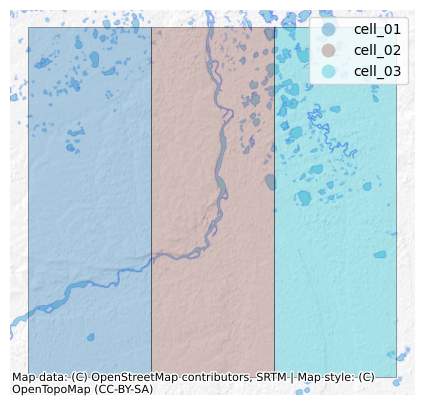

In [4]:
# Plot the 3 cells on a basemap (uses dapper's topounit plotting helpers).
# If `contextily` isn't installed, we fall back to a simple boundary plot.
try:
    from dapper.topounit.topoplot import plot_static

    gdf_plot = gdf_cells.copy()
    gdf_plot["legend_label"] = gdf_plot["gid"]  # plot_static colors by `legend_label`

    plot_static(gdf_plot, basemap="terrain", figsize=(7, 5), alpha=0.35, legend=True)
except ImportError:
    ax = gdf_cells.boundary.plot(figsize=(6, 4))
    gdf_cells.apply(lambda r: ax.text(r.geometry.representative_point().x,
                                     r.geometry.representative_point().y,
                                     r["gid"]),
                    axis=1)
    ax.set_title("Three 0.5° × 0.5° cells (no basemap)")


## Create Domain Class

Any work you do using `dapper` requires that you are explicit about your geographical area(s) of focus. You can be focused on a site (point), a site (polygon/watershed), or many sites/grid cells. All of `dapper`'s functionality requires that you instantiate a `Domain` class. It's easy to do.

`Domain` serves a couple of functions. One, it ensures that your specified area(s) of interest is/are formatted correctly and parseable. Two, it serves as a convenient way to access all of `dapper`'s functionality! No need to import individual functions--you can just use the methods contained in `Domain`.

Before we go on, I want to re-emphasize that this is a `dapper` design choice--**everything starts with a user specifying the area(s) of interest.**

The other thing that you need to decide at this point is if you want exports that are **sites** (each geometry you provide results in a set of input files) or **cellset** (all geometries will be in a single set of files). For this notebook, we're just going to specify `method=sites`, but you can run it again with `method=cellset` if you're unclear about what the difference is.  If you do that, make sure to delete your old output files so you're not confused.

One final note--**the geometry(ies) you provide (as a GeoDataFrame, usually) *must* have a `gid` column with unique values.** This column is used to name and keep track of your geometries. In our case, we've set `gid` to be `["cell_01", "cell_02", "cell_03"]`. `gid` will get converted to a string if you use numeric values.

In [8]:
from dapper import Domain

# Keep polygons in Domain.cells for BOTH modes
domain = Domain.from_provided(
    gdf_cells,
    name="three_cells",
    mode="sites",
    cell_kind="as_provided",
) # OMG so easy

## Met Data

This section has **two parts**:

1) **(Optional) GEE sampling code** that submits export tasks to Google Drive (creates the CSV shards that `dapper` will make ELM-ready). 
2) **Exporting Met data** from `RAW_GEE_CSVS_DIR` into ELM NetCDFs. I have already done the sampling and uploaded the shards to the `dapper` repo, so you can skip step 1 if you want.

Here we will sample and export ERA5-Land hourly data for our 3 cells. There are many options we won't be covering here (e.g. you can export at different time aggregations, there is an `Adapter` for FluxNet/Flux Tower data, etc.)

### 1) (Optional) GEE Sampling ERA5-Land

You will need to have installed `earthengine-api` (it's a `dapper` dependency so you should already have it) **and** run `ee.Authenticate()` at least once.

This will create CSV shards in your specified Google Drive folder. After tasks complete, download them into `RAW_GEE_CSVS_DIR`.

**You must set:**
- `GEE_PROJECT`
- `GDRIVE_FOLDER`

You can also set `skip_tasks=True` when calling `sample_e5lh` to do a dry-run validation without starting tasks. The code below has this set to `False` because I already ran this and exported the files; change it to `True` if you want to sample for yourself. Note that it will take some minutes (depends on GEE's load).

In [9]:
GEE_PROJECT = 'ee-jonschwenk'     # <-- must change me
GDRIVE_FOLDER = "dapper_e2e_3cells" # <-- change me if ya want

# Small time range for an example (adjust as desired)
START_DATE = "2020-01-01"  # earliest available is 1950-01-01 (YYYY-MM-DD)
END_DATE   = "2022-01-01"   # keep small for a demo - can put 2100-01-01 to get the latest available data

import ee
from dapper import sample_e5lh

ee.Initialize(project=GEE_PROJECT)

sampling_params = dict(
    start_date=START_DATE,
    end_date=END_DATE,
    geometries=domain,        # can also pass domain_sites; geometries are the same here
    geometry_id_field="gid",
    gee_bands="elm",                  # "elm" or "all" or explicit list
    gdrive_folder=GDRIVE_FOLDER,
    job_name="e2e_3cells_era5",
    gee_scale="native",
    gee_years_per_task=1,
)

# Starts export tasks unless skip_tasks=True
dom_sample = sample_e5lh(sampling_params, skip_tasks=True) # change skip_tasks to False in order to actually start the tasks on GEE

### 2) Export to ELM-ready

`GEE_MET_SHARDS` should contain one or more `*.csv` shards with a `gid` column matching `cell_01`, `cell_02`, `cell_03`. A "shard" is just a `*.csv` file exported using the `sample_e5lh` function above.

If you have Fluxnet data, you can swap in `FluxnetAdapter` instead of `ERA5Adapter`—the export call is the same, only the adapter/config changes.

In [19]:
from dapper import ERA5Adapter

# Just a little check to make sure your CSV shards are available
def _has_csv_shards(p: Path) -> bool:
    return any(p.glob("*.csv"))

print("CSV shards present:", _has_csv_shards(GEE_MET_SHARDS)) # If this is False, you need to fix something!
print(GEE_MET_SHARDS)
adapter = ERA5Adapter()

CSV shards present: False
X:\Research\NGEE Arctic\dapper\docs\tutorials\end-to-end\docs\data\end-to-end\gee_shards


In [ ]:
# Export MET for sites mode (one MET directory per gid)
# Output: OUT_SITES/<gid>/MET/*.nc
met_sites = domain.export_met(
    src_path=GEE_MET_SHARDS,
    adapter=adapter,
    out_dir=OUT_SITES,
    calendar="noleap", # excludes Feb. 29
    dtime_resolution_hrs=1, # can change if you want. I think even 0.5 works if you want interpolated 30-minute data, but I wouldn't recommend it.
    dformat="BYPASS", # don't change this as no other options are supported. Eventually we might support DATM if needed.
    overwrite=False,
    append_attrs={"dapper_example": "hi mom!"}, # you can add metadata to the exported met netCDFs
)
met_sites

NameError: name 'adapter' is not defined

In [ ]:
# Export MET for cellset mode (one MET directory total)
# Output: OUT_CELLSET/MET/*.nc
if _has_csv_shards(RAW_GEE_CSVS_DIR):
    met_cellset = domain_cellset.export_met(
        src_path=RAW_GEE_CSVS_DIR,
        adapter=adapter,
        out_dir=OUT_CELLSET,
        calendar="noleap",
        dtime_resolution_hrs=1,
        dformat="BYPASS",
        overwrite=False,
        append_attrs={"dapper_example": "e2e_3cells_cellset"},
    )
    met_cellset
else:
    print("No CSV shards found; skipping MET export for cellset mode.")

---

# Domain file export

ELM typically expects a `domain.nc` describing the land mask / cell layout.
We export it for both modes.

In [ ]:
# One domain.nc per gid (sites mode) and one domain.nc total (cellset mode)
domain_sites.export_domain(out_dir=OUT_SITES, overwrite=True)
domain_cellset.export_domain(out_dir=OUT_CELLSET, overwrite=True)

---

# Surface + Landuse export (requires local global NetCDFs)

This section demonstrates **point vs zonal** sampling:

- **nearest (point)**: sample at polygon representative point
- **zonal**: area-weighted intersection of polygon with the source grid

You must provide:
- `SURF_GLOBAL_NC` (surface global)
- `LANDUSE_GLOBAL_NC` (landuse global)

If those paths aren’t set / don’t exist, we skip.

You can also subset variables (or rename variables) during export; this notebook sticks to defaults for clarity.


In [ ]:
def _require_file(path: Path, label: str) -> bool:
    if path is None or str(path).strip() == "" or not path.exists():
        print(f"Skipping {label}: file not set or not found. Set env var and re-run:")
        print(f"  export {label}=/path/to/file.nc")
        return False
    return True

have_surf = _require_file(SURF_GLOBAL_NC, "DAPPER_SURF_GLOBAL_NC")
have_lu   = _require_file(LANDUSE_GLOBAL_NC, "DAPPER_LANDUSE_GLOBAL_NC")

## Surface (sites + cellset) with nearest vs zonal

For brevity:
- sites mode: export **nearest** only (per-geometry outputs)
- cellset mode: export **nearest** and **zonal**, and compare quickly

In [ ]:
import xarray as xr

if have_surf:
    # sites: nearest (point)
    surf_sites = domain_sites.export_surface(
        src_path=SURF_GLOBAL_NC,
        out_dir=OUT_SITES,
        filename="surfdata.nc",
        overwrite=False,
        sampling_method="nearest",
        append_attrs={"dapper_example": "e2e_3cells_sites", "sampling": "nearest"},
    )
    print("sites surface:", surf_sites)

    # cellset: nearest
    surf_cellset_nearest = domain_cellset.export_surface(
        src_path=SURF_GLOBAL_NC,
        out_dir=OUT_CELLSET,
        filename="surfdata_nearest.nc",
        overwrite=False,
        sampling_method="nearest",
        append_attrs={"dapper_example": "e2e_3cells_cellset", "sampling": "nearest"},
    )

    # cellset: zonal
    surf_cellset_zonal = domain_cellset.export_surface(
        src_path=SURF_GLOBAL_NC,
        out_dir=OUT_CELLSET,
        filename="surfdata_zonal.nc",
        overwrite=False,
        sampling_method="zonal",
        append_attrs={"dapper_example": "e2e_3cells_cellset", "sampling": "zonal"},
    )

    print("cellset surface nearest:", surf_cellset_nearest)
    print("cellset surface zonal  :", surf_cellset_zonal)

    # quick compare on one variable if present
    p_near = next(iter(surf_cellset_nearest.values()))
    p_zon  = next(iter(surf_cellset_zonal.values()))
    ds_near = xr.open_dataset(p_near)
    ds_zon  = xr.open_dataset(p_zon)

    common_vars = [v for v in ds_near.data_vars if v in ds_zon.data_vars]
    print("Common vars:", len(common_vars))
    if common_vars:
        v = common_vars[0]
        # Show first cell value
        print("Example var:", v)
        print(" nearest:", float(ds_near[v].isel(lsmlat=0, lsmlon=0).values))
        print(" zonal  :", float(ds_zon[v].isel(lsmlat=0, lsmlon=0).values))
else:
    print("Surface export skipped.")

## Landuse (sites + cellset) with nearest vs zonal

Same pattern as Surface.

In [ ]:
if have_lu:
    # sites: nearest
    lu_sites = domain_sites.export_landuse(
        src_path=LANDUSE_GLOBAL_NC,
        out_dir=OUT_SITES,
        filename="landuse_timeseries.nc",
        overwrite=False,
        sampling_method="nearest",
        append_attrs={"dapper_example": "e2e_3cells_sites", "sampling": "nearest"},
    )
    print("sites landuse:", lu_sites)

    # cellset: nearest + zonal
    lu_cellset_nearest = domain_cellset.export_landuse(
        src_path=LANDUSE_GLOBAL_NC,
        out_dir=OUT_CELLSET,
        filename="landuse_nearest.nc",
        overwrite=False,
        sampling_method="nearest",
        append_attrs={"dapper_example": "e2e_3cells_cellset", "sampling": "nearest"},
    )

    lu_cellset_zonal = domain_cellset.export_landuse(
        src_path=LANDUSE_GLOBAL_NC,
        out_dir=OUT_CELLSET,
        filename="landuse_zonal.nc",
        overwrite=False,
        sampling_method="zonal",
        append_attrs={"dapper_example": "e2e_3cells_cellset", "sampling": "zonal"},
    )

    print("cellset landuse nearest:", lu_cellset_nearest)
    print("cellset landuse zonal  :", lu_cellset_zonal)

    # quick compare if possible
    p_near = next(iter(lu_cellset_nearest.values()))
    p_zon  = next(iter(lu_cellset_zonal.values()))
    ds_near = xr.open_dataset(p_near)
    ds_zon  = xr.open_dataset(p_zon)

    common_vars = [v for v in ds_near.data_vars if v in ds_zon.data_vars]
    print("Common vars:", len(common_vars))
    if common_vars:
        v = common_vars[0]
        # landuse dims vary; try the first index of each dim
        near_val = ds_near[v].isel({d: 0 for d in ds_near[v].dims}).values
        zon_val  = ds_zon[v].isel({d: 0 for d in ds_zon[v].dims}).values
        # cast scalars nicely
        try:
            near_val = float(near_val)
            zon_val = float(zon_val)
        except Exception:
            pass
        print("Example var:", v)
        print(" nearest:", near_val)
        print(" zonal  :", zon_val)
else:
    print("Landuse export skipped.")

---

# Summary: what got written?

This cell prints a small directory tree under `OUT_ROOT`.

In [ ]:
def _tree(root: Path, max_lines: int = 200):
    root = Path(root)
    lines = []
    for p in sorted(root.rglob("*")):
        rel = p.relative_to(root)
        if p.is_dir():
            continue
        lines.append(str(rel))
        if len(lines) >= max_lines:
            lines.append("... (truncated)")
            break
    return "\n".join(lines)

print(_tree(OUT_ROOT))